In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing the required packages**

In [2]:
!pip install -r /content/drive/MyDrive/real_time_fraud_detection/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 88.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)  #here we are setting the option of pandas to display all the columns
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)

**Reading the data**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/real_time_fraud_detection/pay_sim.csv',encoding='utf-8-sig')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
print(df.head())
print('---')
print(df.shape)
print('---')
print(df.info())
print('---')

   step      type    amount     nameorig  oldbalanceorg  newbalanceorig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      namedest  oldbalancedest  newbalancedest  isfraud  isflaggedfraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
---
(6362620, 11)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Dat

**Features discription**

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER. (categorical feature)

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction.

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

In [6]:
df.describe()

,step,amount,oldbalanceorg,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


As we can see from the above table that features such as amount, oldbalanceorg, newbalanceorig, oldbalancedest, newbalancedest are right skewed as their mean value is greater than median value.

**Function to reduce the memory size of a dataset**

In [7]:
from pandas.api.types import is_numeric_dtype
def reduce_memory(df,verbose=True):
    start_memory = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype   #extracting the type of column
        if is_numeric_dtype(df[col]) :  #only if the current column type is number, we change the memory accordingly to the type whether its integer or float
            c_min,c_max = df[col].min(),df[col].max()
            if np.issubdtype(col_type,np.integer):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif np.issubdtype(col_type,np.floating):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:  #if its a string then we change the type to category based on the number of unique values
           if (df[col].nunique() / len(df)) < 0.5:
                df[col] = df[col].astype('category')
    
    end_memory = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_memory:.2f} MB → {end_memory:.2f} MB '
              f'({100 * (start_memory - end_memory) / start_memory:.1f}% reduction)')
    
    return df
df = reduce_memory(df)

Memory usage: 533.97 MB → 309.78 MB (42.0% reduction)


**Data Preprocessing**

checking the null values in the dataset

In [8]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameorig,0
oldbalanceorg,0
newbalanceorig,0
namedest,0
oldbalancedest,0
newbalancedest,0
isfraud,0


As we can see there are no null values in the dataset. Now we will check for duplicates.

In [9]:
df.duplicated().sum()

np.int64(0)

There is also not a single duplicated record in the dataset. So we can say that there is no missing value and no duplicated record in the dataset.

In [10]:
def classify(df):
    target = 'isfraud'
    numerical = [feature for feature in df.select_dtypes(include=np.number).columns if feature!=target]
    categorical = [feature for feature in df.select_dtypes(exclude=np.number).columns if feature!=target]
    return numerical, categorical
numerical, categorical = classify(df)
print(f'Numerical features: {numerical}')
print(f'Categorical features: {categorical}')

Numerical features: ['step', 'amount', 'oldbalanceorg', 'newbalanceorig', 'oldbalancedest', 'newbalancedest', 'isflaggedfraud']
Categorical features: ['type', 'nameorig', 'namedest']


**EDA**

Checking the distribution of the target variable

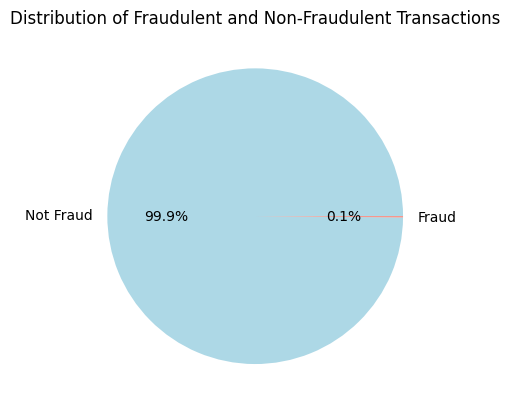

In [11]:
plt.pie(df['isfraud'].value_counts(),labels=['Not Fraud','Fraud'],autopct='%1.1f%%',colors=['lightblue','salmon'])
plt.title('Distribution of Fraudulent and Non-Fraudulent Transactions')
plt.show()

As we can observe that the dataset is highly imbalanced, with only 0.1% of positive class(fraud) and 99.9% of negative class(not fraud)

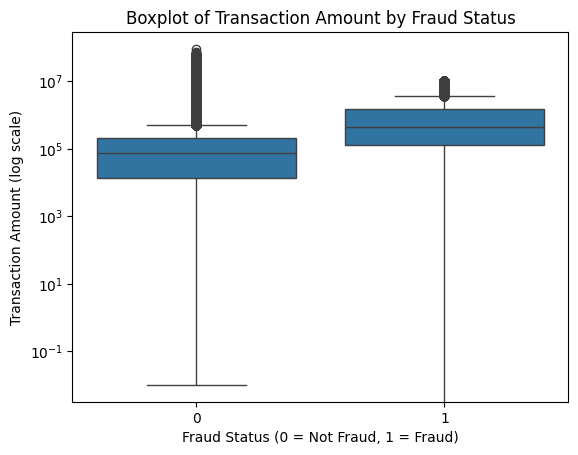

In [12]:
sns.boxplot(x='isfraud',y='amount',data=df)
plt.title('Boxplot of Transaction Amount by Fraud Status')
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Fraud Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount (log scale)')
plt.show()

Due to huge imbalance in dataset, the outliers in non fradulent transactions are dominating the plot as expected.

In [13]:
df['diff'] = abs(df['oldbalanceorg'] - df['newbalanceorig'])  #creating a new feature which is the difference between the old balance and the new balance after the transaction


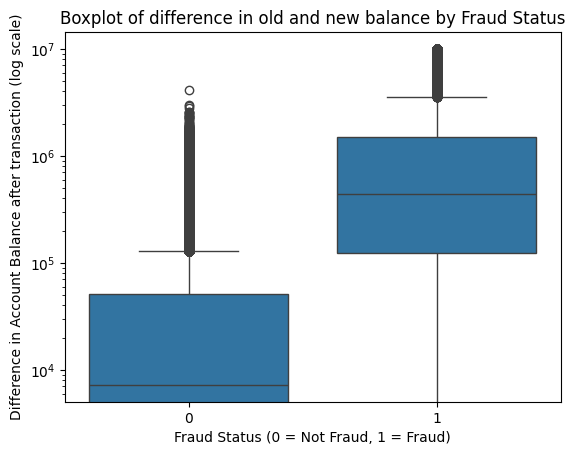

In [14]:
sns.boxplot(x='isfraud',y='diff',data=df)
plt.title('Boxplot of difference in old and new balance by Fraud Status')  
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Fraud Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Difference in Account Balance after transaction (log scale)')
plt.show()

As we can observe from the above plot that, the difference in new and old balance is very high for fraudulent transaction compared to non_fraudulent transaction.

In [15]:
df.columns

Index(['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud', 'diff'],
      dtype='object')

In [16]:
df['day'] = np.ceil(df['step'] / 24).astype(int)  #converting the time step into days by dividing the step by 24 and taking the ceiling to get the day number
df['day_name'] = df['day'].map({1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday',7:'Sunday'})  #mapping the day number to the day name

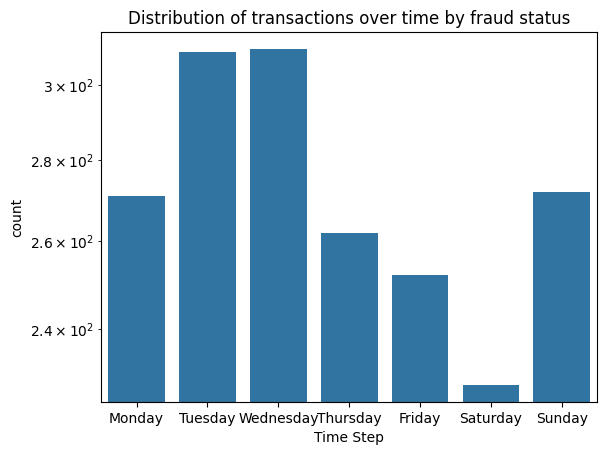

In [17]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='day_name',data=df[df['isfraud']==1],order=day_order)
plt.yscale('log')  # Log scale to better visualize the distribution
plt.title('Distribution of transactions over time by fraud status')
plt.xlabel('Time Step')
plt.show()

From the above plot, we can observe that there is a high fraudulent transaction on tuesday and wednesday where as the saturday had the least fraudulent transaction

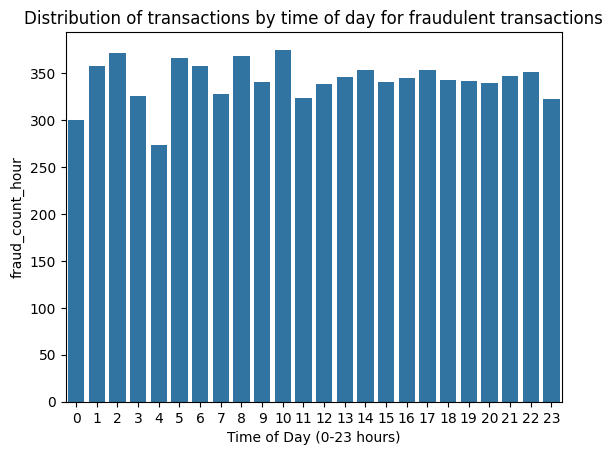

In [18]:
df['hour_of_day']=df['step']%24
fraud_by_hour = df[df['isfraud']==1].groupby('hour_of_day')['isfraud'].count().reset_index(name='fraud_count_hour')
sns.barplot(data=fraud_by_hour,x='hour_of_day',y='fraud_count_hour')
plt.title('Distribution of transactions by time of day for fraudulent transactions')
plt.xlabel('Time of Day (0-23 hours)')
plt.show()

"From the above analysis, we can see that most fraudulent transactions occur between 1 AM and 10 AM, with a peak between 5 AM and 8 AM. This could be attributed to two factors: first, account holders are less vigilant during early morning hours and may not notice suspicious activity immediately; second, banks typically have reduced real-time monitoring during off-peak hours, giving fraudsters a larger window of opportunity."

In [19]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,diff,day,day_name,hour_of_day
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,9839.640625,1,Monday,1
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1864.279297,1,Monday,1
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,181.000000,1,Monday,1
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,181.000000,1,Monday,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,11668.140625,1,Monday,1


In [20]:
def classify_dest(df):
    if df.namedest.startswith('M'):
        return 'Merchant'
    elif df.namedest.startswith('C'):
        return 'Customer'
df['dest_type'] = df.apply(classify_dest, axis=1)  #creating a new feature dest_type which classifies the destination account as either a merchant or a customer based on the prefix of the namedest column    

In [21]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,diff,day,day_name,hour_of_day,dest_type
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,9839.640625,1,Monday,1,Merchant
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1864.279297,1,Monday,1,Merchant
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,181.000000,1,Monday,1,Customer
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,181.000000,1,Monday,1,Customer
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,11668.140625,1,Monday,1,Merchant


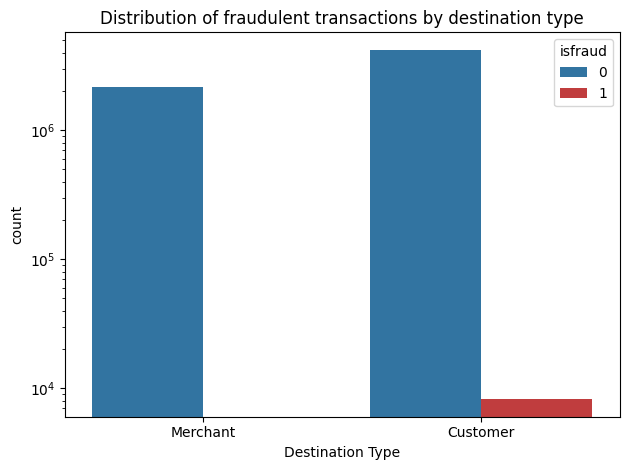

In [22]:
sns.countplot(data=df, x='dest_type', hue='isfraud', palette=['#1f77b4', '#d62728'])
plt.title('Distribution of fraudulent transactions by destination type')
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Destination Type')
plt.tight_layout()
plt.show()

"All fraudulent transactions were directed exclusively to customer destination accounts, with no fraud recorded against merchant destinations. This aligns with the dataset documentation, which states that balance information for merchant accounts is unavailable. As a result, the destination account type serves as a strong binary feature — transactions directed toward merchant accounts carry zero fraud risk by design in this dataset."

In [23]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,diff,day,day_name,hour_of_day,dest_type
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,9839.640625,1,Monday,1,Merchant
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1864.279297,1,Monday,1,Merchant
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,181.000000,1,Monday,1,Customer
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,181.000000,1,Monday,1,Customer
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,11668.140625,1,Monday,1,Merchant


**Feature Engineering**

In [24]:
df['log_amount'] = np.log1p(df['amount'])  #creating a new feature log_amount which is the logarithm of the transaction amount to reduce the skewness of the distribution
df['log_diff'] = np.log1p(df['diff'])  #creating a new feature log_diff which is the logarithm of the difference in account balance to reduce the skewness of the distribution
df['critical_transaction'] = (df['amount'] > 200000).astype(int)  #creating a new feature critical_amount which indicates whether the transaction amount is greater than 200000 or not, as we can see from the boxplot that there are some transactions with very high amounts which are likely to be fraudulent
df['is_round'] = (df['amount'] % 1000 == 0).astype(int)  #creating a new feature is_round which indicates whether the transaction amount is a round number (multiple of 1000) or not, as fraudsters often use round numbers to avoid detection
#and this 200000 threshold is chosen based on the context of the dataset.

In [25]:
df = df.drop(columns = ['diff'])  #dropping the original amount and diff columns as we have created new features log_amount and log_diff which are more suitable for modeling

In [26]:
df.head()
df.groupby('type')['isfraud'].mean().reset_index(name='fraud_rate').sort_values(by='fraud_rate',ascending=False)

/tmp/ipykernel_242/2526500494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('type')['isfraud'].mean().reset_index(name='fraud_rate').sort_values(by='fraud_rate',ascending=False)


,type,fraud_rate
4,TRANSFER,0.007688
1,CASH_OUT,0.001840
0,CASH_IN,0.000000
2,DEBIT,0.000000
3,PAYMENT,0.000000


**From the above analysis, we can observe that the 'transfer' and 'cash_out' transaction types have significantly higher fraud rates compared to other transaction types. This insight can be crucial for building a fraud detection model, as it indicates that these transaction types are more likely to be associated with fraudulent activities. Therefore, we should consider giving more weight to these features in our model or even creating additional features based on these transaction types to improve the model's performance in detecting fraud.**

In [27]:
df['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)  #creating a new feature is_transfer which indicates whether the transaction type is a transfer or not
df['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)  #creating a new feature is_cash_out which indicates whether the transaction type is a cash out or not   


In [28]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,day,day_name,hour_of_day,dest_type,log_amount,log_diff,critical_transaction,is_round,is_transfer,is_cash_out
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,1,Monday,1,Merchant,9.194276,9.194276,0,0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1,Monday,1,Merchant,7.531167,7.531166,0,0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,1,Monday,1,Customer,5.204007,5.204007,0,0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,1,Monday,1,Customer,5.204007,5.204007,0,0,0,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,1,Monday,1,Merchant,9.364703,9.364703,0,0,0,0


From the context of dataset, we must drop features such as oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest and any features made up of using those features, cause those features are not available at the time of transaction and they are only updated after the transaction is completed, so we cannot use those features for real-time fraud detection as they will not be available at the time of prediction.
So we must drop them before training the model

In [29]:
df = df.drop(columns = ['type','nameorig','isflaggedfraud','namedest','oldbalanceorg','newbalanceorig','oldbalancedest','newbalancedest','log_diff'])  #dropping the original balance columns as we have created new features log_diff which captures the difference in balance and is more suitable for modeling

In [30]:
df.head()

,step,amount,isfraud,day,day_name,hour_of_day,dest_type,log_amount,critical_transaction,is_round,is_transfer,is_cash_out
0,1,9839.639648,0,1,Monday,1,Merchant,9.194276,0,0,0,0
1,1,1864.280029,0,1,Monday,1,Merchant,7.531167,0,0,0,0
2,1,181.000000,1,1,Monday,1,Customer,5.204007,0,0,1,0
3,1,181.000000,1,1,Monday,1,Customer,5.204007,0,0,0,1
4,1,11668.139648,0,1,Monday,1,Merchant,9.364703,0,0,0,0


In [31]:
df['is_merchant_dest'] = (df['dest_type'] == 'Merchant').astype(int)  #creating a new feature is_merchant_dest which indicates whether the destination account is a merchant or not based on the dest_type column   


In [32]:
df = df.drop(columns = ['dest_type'])  #dropping the dest_type column as we have created a new feature is_merchant_dest which captures the same information in a more suitable format for modeling

In [33]:
df.head()

,step,amount,isfraud,day,day_name,hour_of_day,log_amount,critical_transaction,is_round,is_transfer,is_cash_out,is_merchant_dest
0,1,9839.639648,0,1,Monday,1,9.194276,0,0,0,0,1
1,1,1864.280029,0,1,Monday,1,7.531167,0,0,0,0,1
2,1,181.000000,1,1,Monday,1,5.204007,0,0,1,0,0
3,1,181.000000,1,1,Monday,1,5.204007,0,0,0,1,0
4,1,11668.139648,0,1,Monday,1,9.364703,0,0,0,0,1


In [34]:
df['day_of_week'] = (df['day'] - 1) % 7  # 0=Monday, 1=Tuesday, ... 6=Sunday  
df=df.drop(columns=['day_name','day'])  #dropping the day_name column as we have created a new feature day_of_week which captures the same information in a more suitable format for modeling

In [35]:
df['is_night_transaction'] = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] <= 6)).astype(int)  #creating a new feature is_night_transaction which indicates whether the transaction occurred during the night hours (0-6) or not, as fraudulent transactions may be more likely to occur during these hours    
df=df.drop(columns=['amount'])  #dropping the hour_of_day column as we have created a new feature is_night_transaction which captures the same information in a more suitable format for modeling

In [36]:
df=df.drop(columns = ['step'])
df.head()

,isfraud,hour_of_day,log_amount,critical_transaction,is_round,is_transfer,is_cash_out,is_merchant_dest,day_of_week,is_night_transaction
0,0,1,9.194276,0,0,0,0,1,0,1
1,0,1,7.531167,0,0,0,0,1,0,1
2,1,1,5.204007,0,0,1,0,0,0,1
3,1,1,5.204007,0,0,0,1,0,0,1
4,0,1,9.364703,0,0,0,0,1,0,1


**Model Training**

splitting the dataset into train and test sets

In [37]:
X, y = df.drop('isfraud', axis=1), df['isfraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  #here we are splitting the dataset into training and testing sets with stratification to maintain the class distribution in both sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5090096, 9), (1272524, 9), (5090096,), (1272524,))

Preprocessing pipeline

In [38]:
scalar = RobustScaler()
X_train['log_amount'] = scalar.fit_transform(X_train[['log_amount']])  #scaling the log_amount feature using RobustScaler to reduce the impact of outliers on the model training
X_test['log_amount'] = scalar.transform(X_test[['log_amount']])  

In [39]:
import pickle


with open('/content/drive/MyDrive/real_time_fraud_detection/preprocessors.pkl', 'wb') as f:
    pickle.dump(scalar, f)

print("Saved to Google Drive ✓")

Saved to Google Drive ✓


Since the dataset is highly imbalanced, we will be using the class_weight parameter in our models to give more weight to the minority class (fraudulent transactions) during training. This helps the model to learn better from the minority class and improve its performance in detecting fraudulent transactions. And we will evaluate the model with balanced class weight and without balanced class weight, but with SMOTE oversampling technique to handle the class imbalance. And choose the one with best PR-AUC, Recall, ROC-AUC

In [40]:
model1 = LGBMClassifier(verbose=-1, class_weight='balanced', n_estimators=100, random_state=42)
model1.fit(X_train, y_train)
y_pred_cw = model1.predict(X_test)  #predicting the class labels for test dataset
y_prob_cw = model1.predict_proba(X_test)[:, 1]   #selecting all rows but only the last or second column for fraud probabilities
#here we are predicting the probabilities of the positive class (fraud) for the test set, which can be used for further evaluation metrics like ROC-AUC or precision-recall curves.

Using SMOTE to balance the dataset to increase the number of minority class (fraud) 

In [41]:
smote = SMOTE(random_state=42)  #here we are using SMOTE to handle the class imbalance in the dataset by generating synthetic samples for the minority class (fraud) based on the existing samples in the training set, which can help improve the performance of the model in detecting fraudulent transactions.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)  #here we are applying SMOTE to the training data to create a new balanced training set with synthetic samples for the minority class (fraud), which can help improve the model's ability to learn from the data and detect fraudulent transactions more effectively.
model2 = LGBMClassifier(verbose=-1, n_estimators=100, random_state=42)
model2.fit(X_train_smote, y_train_smote)
y_pred_smote = model2.predict(X_test)  #predicting the class labels for test dataset
y_prob_smote = model2.predict_proba(X_test)[:, 1]  #here we are predicting the probabilities of the positive class (fraud) for the test set, which can be used for further evaluation metrics like ROC-AUC or precision-recall curves.

In [42]:
#here we are comparing the evaluation metrics of the two models, one trained with class weights and the other trained with SMOTE, to see which approach performs better in terms of handling class imbalance in fraud detection. We are calculating metrics such as ROC-AUC, PR-AUC, Recall, and Precision for both models and presenting them in a tabular format for easy comparison.
comparison = {
    'class_weight': {
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_cw), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_prob_cw), 4),
        'Recall'   : round(recall_score(y_test, y_pred_cw), 4),
        'Precision': round(precision_score(y_test, y_pred_cw), 4),
    },
    'SMOTE': {
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_smote), 4),
        'PR-AUC'   : round(average_precision_score(y_test, y_prob_smote), 4),
        'Recall'   : round(recall_score(y_test, y_pred_smote), 4),
        'Precision': round(precision_score(y_test, y_pred_smote), 4),
    }
}
print(pd.DataFrame(comparison).T)

              ROC-AUC  PR-AUC  Recall  Precision
class_weight   0.9541  0.3679  0.8558     0.0101
SMOTE          0.9512  0.3677  0.8515     0.0098


From the above dataframe we can see that the model trained with class weights has a higher ROC-AUC and PR-AUC compared to the model trained with SMOTE, indicating that it performs better in distinguishing between fraudulent and non-fraudulent transactions. Additionally, the class weight model has a higher precision, which means it is better at correctly identifying fraudulent transactions while minimizing false positives.

Multi-model comparison

In [43]:
models = {
'LightGBM': LGBMClassifier(verbose=-1, class_weight='balanced',
                                n_estimators=100, random_state=42),
'XGBoost': XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),    #here we are using scale_pos_weight to handle the class imbalance in the dataset by balanced weight  to both classes based on their ratio, which helps the model to effectively classifying the fraudulent transactions.
                              n_estimators=100, random_state=42, eval_metric='aucpr'),
'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                            random_state=42, n_jobs=-1),
'Logistic Regression': LogisticRegression(class_weight='balanced',
                                               max_iter=1000, random_state=42)
}
result = {}
for name,model in models.items():
    model.fit(X_train, y_train)  #fitting the model on the training data
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  #only extracting the probability of the positive class (fraud)
    result[name] = {
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, y_prob), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4)
    }
df = pd.DataFrame(result).T

In [44]:
df

,F1,ROC-AUC,PR-AUC,Recall,Precision
LightGBM,0.0199,0.9541,0.3679,0.8558,0.0101
XGBoost,0.0228,0.9559,0.3917,0.8259,0.0116
Random Forest,0.3711,0.7330,0.3167,0.3122,0.4572
Logistic Regression,0.0111,0.9189,0.0537,0.8704,0.0056


From the above analysis, we can observe that Random Forest is performing the best in overall metrics among the models we trained, with the highest F1 score. This indicates that Random Forest is more effective in detecting fraudulent transactions in this dataset compared to LightGBM, XGBoost, and Logistic Regression. The use of class weights and handling class imbalance has likely contributed to the improved performance of the models, especially for Random Forest.

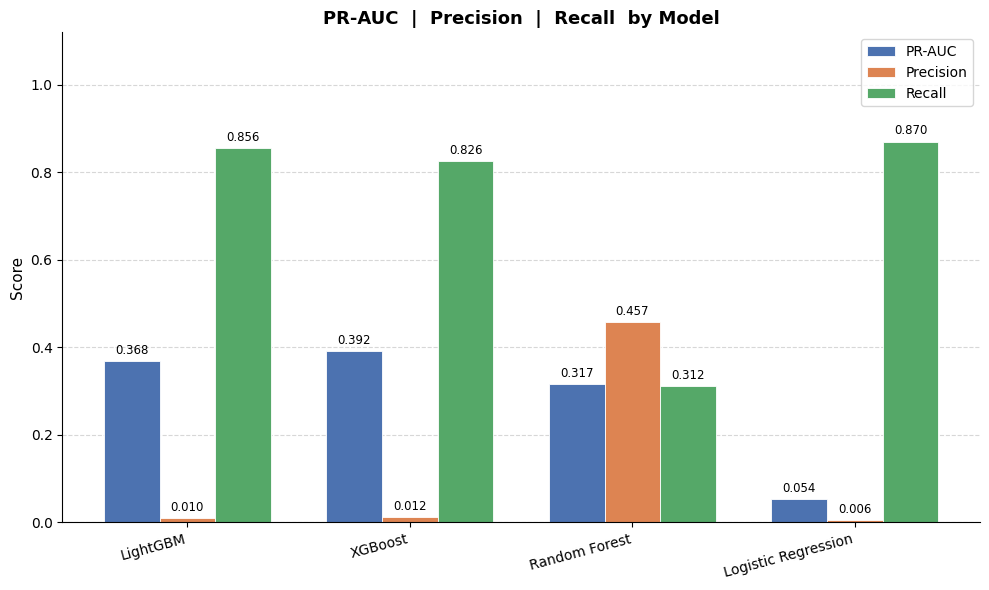

In [45]:
metrics   = ['PR-AUC', 'Precision', 'Recall']
colors    = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green
n_models  = len(df)
n_metrics = len(metrics)

x     = np.arange(n_models)
width = 0.25                                    # bar width

fig, ax = plt.subplots(figsize=(10, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(
        x + i * width,
        df[metric],
        width,
        label=metric,
        color=color,
        edgecolor='white',
        linewidth=0.6
    )
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8.5)
ax.set_xticks(x + width)                        # center ticks
ax.set_xticklabels(df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('PR-AUC  |  Precision  |  Recall  by Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.12)                            # headroom for labels
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

class for early stopping for optuna trial

In [46]:
class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_value = None
        self.stagnant_trials = 0

    def __call__(self, study, trial):
        if self.best_value is None or study.best_value > self.best_value:
            self.best_value = study.best_value
            self.stagnant_trials = 0
        else:
            self.stagnant_trials += 1

        if self.stagnant_trials >= self.patience:
            print(f"Stopping study: No improvement for {self.patience} trials.")
            study.stop()

**Experimentation of different models and hyperparameter tuning**

In [ ]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # for cleaner output

class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_value = None
        self.stagnant_trials = 0

    def __call__(self, study, trial):
        if self.best_value is None or study.best_value > self.best_value:
            self.best_value = study.best_value
            self.stagnant_trials = 0
        else:
            self.stagnant_trials += 1
        if self.stagnant_trials >= self.patience:
            print(f"Stopping study: No improvement for {self.patience} trials.")
            study.stop()


def optimize_model_cv(model_name, X, y, n_trials=20):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    def objective(trial):
        if model_name == 'Random Forest':
            params = {
                'n_estimators'     : trial.suggest_int('n_estimators', 50, 150),
                'max_depth'        : trial.suggest_int('max_depth', 3, 7),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 6),
                'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
                'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                'class_weight'     : 'balanced',
                'random_state'     : 42,
                'n_jobs'           : -1,    
            }
            model = RandomForestClassifier(**params)

        elif model_name == 'XGBoost':
            params = {
                'n_estimators'    : trial.suggest_int('n_estimators', 100, 300),
                'max_depth'       : trial.suggest_int('max_depth', 3, 10),
                'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'scale_pos_weight': len(y[y==0]) / len(y[y==1]),
                'random_state'    : 42,
                'eval_metric'     : 'aucpr',
                'device'          : 'cuda',
                'tree_method'     : 'hist'
            }
            model = XGBClassifier(**params)

        elif model_name == 'LightGBM':
            params = {
                'n_estimators'     : trial.suggest_int('n_estimators', 100, 300),
                'max_depth'        : trial.suggest_int('max_depth', 3, 10),
                'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
                'scale_pos_weight' : len(y[y==0]) / len(y[y==1]),
                'random_state'     : 42,
                'device'           : 'gpu',
            }
            model = LGBMClassifier(**params)

        #  n_jobs=1 for GPU models to avoid conflicts
        n_jobs = -1 if model_name == 'Random Forest' else 1
        scores = cross_val_score(
            model, X, y,
            cv=cv,
            scoring='average_precision',
            n_jobs=n_jobs
        )
        return scores.mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=42)     # ✅ reproducible
    )
    early_stop = EarlyStoppingCallback(patience=10)

    study.optimize(
        objective,
        n_trials=n_trials,
        n_jobs=1,                       # ✅ sequential for GPU safety
        callbacks=[early_stop]
    )

    print(f'\n{model_name} — Best CV PR-AUC: {study.best_value:.4f}')
    print(f'Best Params: {study.best_params}')
    return study.best_params, study.best_value


# ── Run Optimization ───────────────────────────────────────────
rf_cv_params,   rf_cv_score   = optimize_model_cv('Random Forest', X_train, y_train, n_trials=20)
xgb_cv_params,  xgb_cv_score  = optimize_model_cv('XGBoost',       X_train, y_train, n_trials=20)
lgbm_cv_params, lgbm_cv_score = optimize_model_cv('LightGBM',      X_train, y_train, n_trials=20)

print(f'\nRandom Forest CV Optuna → PR-AUC: {rf_cv_score:.4f}')
print(f'XGBoost       CV Optuna → PR-AUC: {xgb_cv_score:.4f}')
print(f'LightGBM      CV Optuna → PR-AUC: {lgbm_cv_score:.4f}')

[I 2026-05-13 03:02:27,289] A new study created in memory with name: no-name-e20d5cdc-c3f6-45f5-bdc0-2b7eb595c808
[I 2026-05-13 03:11:11,216] Trial 0 finished with value: 0.1491625414902504 and parameters: {'n_estimators': 265, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.1491625414902504.
[I 2026-05-13 03:28:34,744] Trial 1 finished with value: 0.2775767474614726 and parameters: {'n_estimators': 295, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.2775767474614726.
[I 2026-05-13 03:38:37,661] Trial 2 finished with value: 0.19474953941155596 and parameters: {'n_estimators': 247, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: 0.2775767474614726.
[I 2026-05-13 03:47:53,707] Trial 3 finished with value: 0.19698341634871777 and parameters: {'n_estimators': 222, 'max_depth': 4, 'mi